In [1]:
import pandas as pd
from pandas.tseries.offsets import MonthEnd
import numpy as np
from datetime import datetime, timedelta, date
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
# Генерируем случайные метрики для проведения анализа

np.random.seed(42)
random.seed(42)

# Генерируем df2: информация о сотрудниках
employee_ids = list(range(1, 1100))
dt_starts = [datetime(2023, 1, 1) + timedelta(days=random.randint(0, 360)) for _ in employee_ids]
salaries = [random.randint(3000, 7000) for _ in employee_ids]

df2 = pd.DataFrame({
    'id': employee_ids,
    'dt_start': dt_starts,
    'salary': salaries
})

# Генерируем df1: записи о днях работы
records = []
for emp_id, start_date in zip(employee_ids, dt_starts):
    work_days = sorted(start_date + timedelta(days=i) for i in random.sample(range(100), k=15))
    for day in work_days:
        crystals = random.randint(0, 10)
        records.append({'id': emp_id, 'dt': day, 'crystals': crystals})

df1 = pd.DataFrame(records)

# Display dataframes
print("df1:")
print(df1.head(5))

print("\ndf2:")
print(df2.head(5))


df1:
   id         dt  crystals
0   1 2023-12-18         7
1   1 2023-12-23         7
2   1 2023-12-24         4
3   1 2023-12-30         6
4   1 2024-01-02         8

df2:
   id   dt_start  salary
0   1 2023-11-24    5907
1   2 2023-02-27    3648
2   3 2023-01-13    4272
3   4 2023-05-21    5256
4   5 2023-05-06    3056


In [3]:
# # Складываем в отдельный csv для репродукции анализа
# df1.to_csv('df1.csv', index=False)
# df2.to_csv('df2.csv', index=False)

# Читаем из сохраненного csv
df1 = pd.read_csv('df1.csv')
df2 = pd.read_csv('df2.csv')
df1['dt'] = pd.to_datetime(df1['dt'], errors='coerce')
df2['dt_start'] = pd.to_datetime(df2['dt_start'], errors='coerce')



In [24]:
df1.dt.min(), df1.dt.max(), 

(Timestamp('2023-01-02 00:00:00'), Timestamp('2024-04-03 00:00:00'))

In [4]:
df1.info(), df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16485 entries, 0 to 16484
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        16485 non-null  int64         
 1   dt        16485 non-null  datetime64[ns]
 2   crystals  16485 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 386.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1099 entries, 0 to 1098
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        1099 non-null   int64         
 1   dt_start  1099 non-null   datetime64[ns]
 2   salary    1099 non-null   int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 25.9 KB


(None, None)

In [5]:
# Предобрабатываем данные для удобства анализа
df1['dt_month'] = df1['dt'].apply(lambda x: date(x.year, x.month, 1))
df2['dt_month'] = df2['dt_start'].apply(lambda x: date(x.year, x.month, 1))

In [6]:
# Часть 1: общая описательная статистика

# Часть 1.1: количество добываемых кристаллов + кол-во работавших сотрудников 
monthly_stats = df1.groupby('dt_month').agg(
    total_crystals=('crystals', 'sum'),
    unique_employees=('id', pd.Series.nunique),
).reset_index()

# среднее кол-во кристалов на сотрудника
monthly_stats['avg_crystals_per_employee'] = monthly_stats['total_crystals'] / monthly_stats['unique_employees']


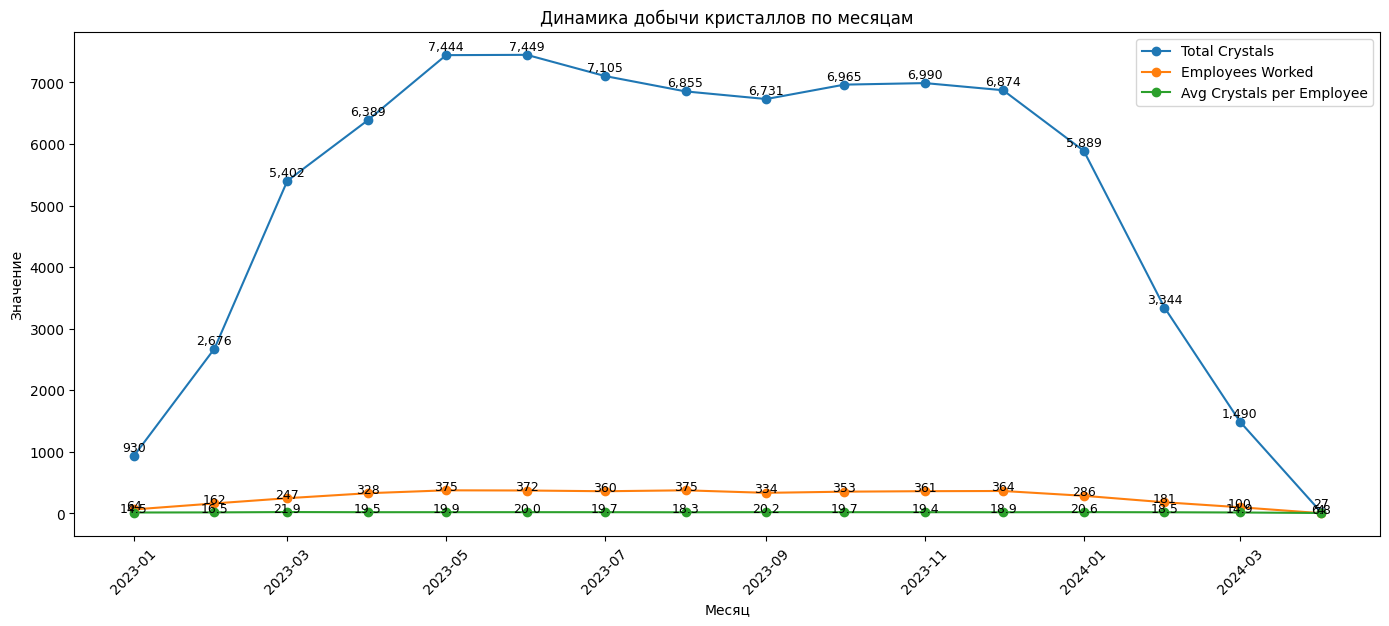

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(monthly_stats['dt_month'], monthly_stats['total_crystals'], marker='o', label='Total Crystals')
for i, row in monthly_stats.iterrows():
    plt.text(row['dt_month'], row['total_crystals'] + 0.01 * monthly_stats['total_crystals'].max(),
             f"{int(row['total_crystals']):,}", ha='center', fontsize=9)

plt.plot(monthly_stats['dt_month'], monthly_stats['unique_employees'], marker='o', label='Employees Worked')
for i, row in monthly_stats.iterrows():
    plt.text(row['dt_month'], row['unique_employees'] + 0.01 * monthly_stats['unique_employees'].max(),
             f"{int(row['unique_employees'])}", ha='center', fontsize=9)

plt.plot(monthly_stats['dt_month'], monthly_stats['avg_crystals_per_employee'], marker='o', label='Avg Crystals per Employee')
for i, row in monthly_stats.iterrows():
    plt.text(row['dt_month'], row['avg_crystals_per_employee'] + 0.01 * monthly_stats['avg_crystals_per_employee'].max(),
             f"{row['avg_crystals_per_employee']:.1f}", ha='center', fontsize=9)

plt.title('Динамика добычи кристаллов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Значение')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


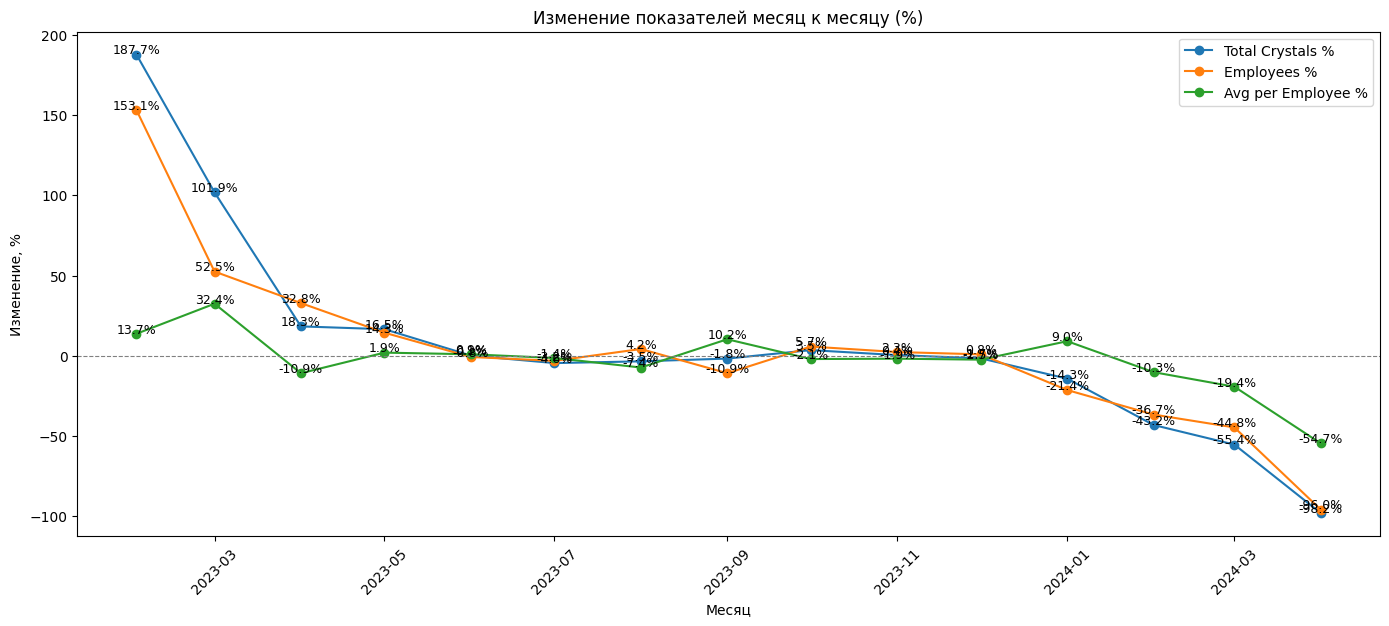

In [8]:
# Ежемесячное изменение динамики метрик
monthly_stats_pct = monthly_stats.copy()
monthly_stats_pct = monthly_stats_pct.sort_values('dt_month').reset_index(drop=True)
monthly_stats_pct['crystals_pct'] = monthly_stats_pct['total_crystals'].pct_change() * 100
monthly_stats_pct['employees_pct'] = monthly_stats_pct['unique_employees'].pct_change() * 100
monthly_stats_pct['avg_per_employee_pct'] = monthly_stats_pct['avg_crystals_per_employee'].pct_change() * 100

plt.figure(figsize=(14, 6))

# Crystals, MoM %
plt.plot(monthly_stats_pct['dt_month'], monthly_stats_pct['crystals_pct'], marker='o', label='Total Crystals %')
for i, row in monthly_stats_pct.iterrows():
    if pd.notnull(row['crystals_pct']):
        plt.text(row['dt_month'], row['crystals_pct'] + 0.5,
                 f"{row['crystals_pct']:.1f}%", ha='center', fontsize=9)

# Employees, MoM %
plt.plot(monthly_stats_pct['dt_month'], monthly_stats_pct['employees_pct'], marker='o', label='Employees %')
for i, row in monthly_stats_pct.iterrows():
    if pd.notnull(row['employees_pct']):
        plt.text(row['dt_month'], row['employees_pct'] + 0.5,
                 f"{row['employees_pct']:.1f}%", ha='center', fontsize=9)

# Avg Crystals per Employee, MoM %
plt.plot(monthly_stats_pct['dt_month'], monthly_stats_pct['avg_per_employee_pct'], marker='o', label='Avg per Employee %')
for i, row in monthly_stats_pct.iterrows():
    if pd.notnull(row['avg_per_employee_pct']):
        plt.text(row['dt_month'], row['avg_per_employee_pct'] + 0.5,
                 f"{row['avg_per_employee_pct']:.1f}%", ha='center', fontsize=9)


plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Изменение показателей месяц к месяцу (%)')
plt.xlabel('Месяц')
plt.ylabel('Изменение, %')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [9]:
# Количество новых сотрудников по месяцам
new_employees_monthly = df2.groupby('dt_month').agg(
    new_employees=('id', 'nunique')
).reset_index()

# Количество уникальных сотрудников, работавших в месяце
active_employees_monthly = df1.groupby('dt_month').agg(
    active_employees=('id', 'nunique')
).reset_index()

# Количество отработанных человеко-дней в месяц
worked_days_monthly = df1.groupby('dt_month').agg(
    person_days=('id', 'count')
).reset_index()


employee_activity = pd.merge(new_employees_monthly, active_employees_monthly, on='dt_month', how='outer')
employee_activity = pd.merge(employee_activity, worked_days_monthly, on='dt_month', how='outer')

employee_activity = employee_activity.sort_values('dt_month').fillna(0)

employee_activity[['new_employees', 'active_employees', 'person_days']] = \
    employee_activity[['new_employees', 'active_employees', 'person_days']].astype(int)


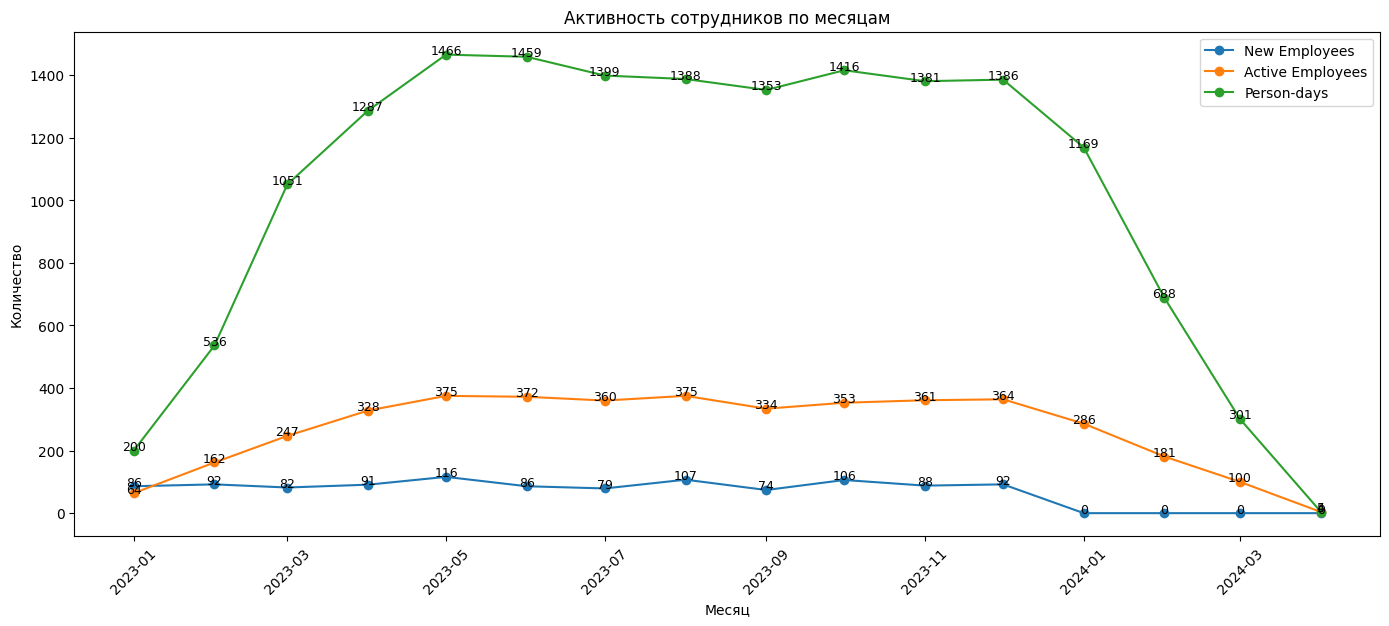

In [10]:

plt.figure(figsize=(14, 6))
plt.plot(employee_activity['dt_month'], employee_activity['new_employees'], marker='o', label='New Employees')
plt.plot(employee_activity['dt_month'], employee_activity['active_employees'], marker='o', label='Active Employees')
plt.plot(employee_activity['dt_month'], employee_activity['person_days'], marker='o', label='Person-days')

for col in ['new_employees', 'active_employees', 'person_days']:
    for i, row in employee_activity.iterrows():
        plt.text(row['dt_month'], row[col] + 0.5, f"{row[col]}", ha='center', fontsize=9)

plt.title('Активность сотрудников по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

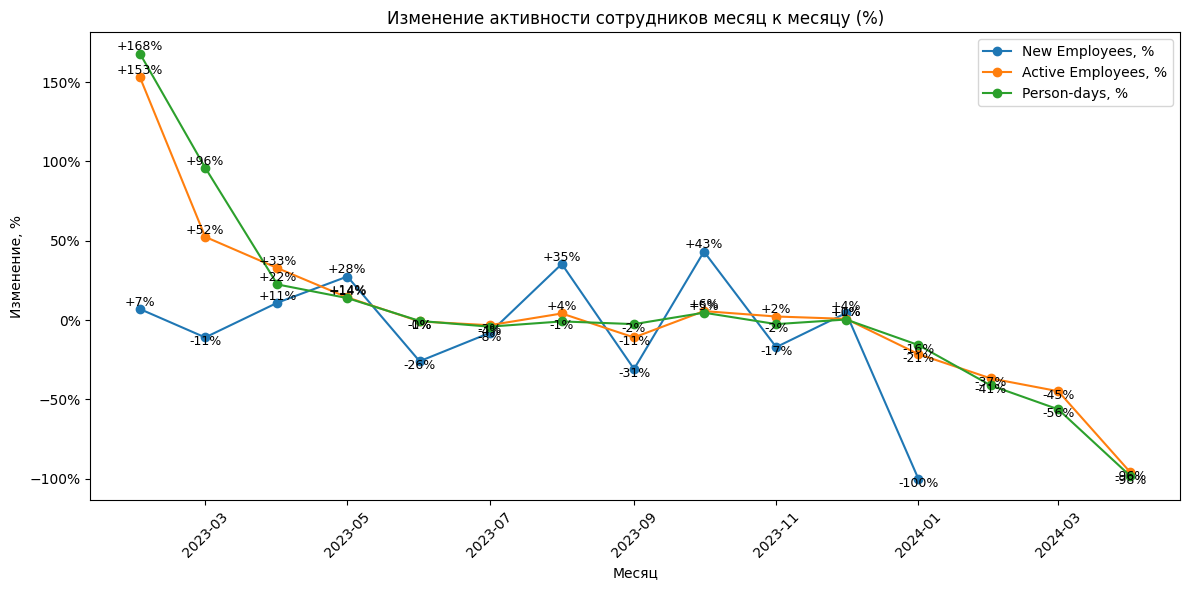

In [27]:
employee_activity = employee_activity.sort_values('dt_month').reset_index(drop=True)

employee_activity['new_employees_pct'] = employee_activity['new_employees'].pct_change() * 100
employee_activity['active_employees_pct'] = employee_activity['active_employees'].pct_change() * 100
employee_activity['person_days_pct'] = employee_activity['person_days'].pct_change() * 100


employee_activity[['new_employees_pct', 'active_employees_pct', 'person_days_pct']] = \
    employee_activity[['new_employees_pct', 'active_employees_pct', 'person_days_pct']].round(1)

plt.figure(figsize=(12, 6))


plt.plot(employee_activity['dt_month'], employee_activity['new_employees_pct'], marker='o', label='New Employees, %')
plt.plot(employee_activity['dt_month'], employee_activity['active_employees_pct'], marker='o', label='Active Employees, %')
plt.plot(employee_activity['dt_month'], employee_activity['person_days_pct'], marker='o', label='Person-days, %')


for col in ['new_employees_pct', 'active_employees_pct', 'person_days_pct']:
    for i, row in employee_activity.iterrows():
        if pd.notnull(row[col]):
            plt.text(row['dt_month'], row[col] + (2 if row[col] >= 0 else -5),
                     f"{row[col]:+.0f}%", ha='center', fontsize=9)


plt.title('Изменение активности сотрудников месяц к месяцу (%)')
plt.xlabel('Месяц')
plt.ylabel('Изменение, %')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
end_date = df1['dt'].max()

# Учитываем только рабочие дни (пн-пт)
df1 = df1[df1['dt'].dt.weekday < 5]

# Отработанные дни на сотрудника
worked_days = df1.groupby('id').agg(worked_days=('dt', 'nunique')).reset_index()

# 2. Потенциальные рабочие дни (пн-пт между датой найма и текущей датой)
df2 = df2[df2['dt_start'] <= end_date].copy()
df2['potential_days'] = df2['dt_start'].apply(
    lambda x: pd.bdate_range(x, end_date).size
)

# Объединение
utilization = df2.merge(worked_days, on='id', how='left').fillna(0)
utilization['worked_days'] = utilization['worked_days'].astype(int)
utilization['utilization_ratio'] = utilization['worked_days'] / utilization['potential_days']
utilization['cohort'] = utilization['dt_start'].dt.to_period('M').dt.to_timestamp()

# Сезон
def get_season(date):
    m = date.month
    return (
        'Winter' if m in [12, 1, 2] else
        'Spring' if m in [3, 4, 5] else
        'Summer' if m in [6, 7, 8] else
        'Autumn'
    )
utilization['season'] = utilization['dt_start'].apply(get_season)


# === Расчёты для визуализаций ===

# 1. Когортная утилизация
cohort_utilization = utilization.groupby('cohort').agg(
    avg_utilization=('utilization_ratio', 'mean'),
    employees=('id', 'count')
).reset_index()

# 2. Месячная утилизация
df1['dt_month'] = df1['dt'].dt.to_period('M').dt.to_timestamp()
monthly_utilization = df1.groupby(['id', 'dt_month']).agg(
    worked_days=('dt', 'nunique')
).reset_index()
monthly_utilization = monthly_utilization.merge(df2[['id', 'dt_start']], on='id', how='left')

# Фильтрация месяцев до найма
monthly_utilization = monthly_utilization[monthly_utilization['dt_month'] >= monthly_utilization['dt_start'].dt.to_period('M').dt.to_timestamp()]
monthly_utilization['month_days'] = monthly_utilization.apply(
    lambda row: pd.bdate_range(row['dt_month'], row['dt_month'] + MonthEnd(0)).size, axis=1
)
monthly_utilization['utilization'] = monthly_utilization['worked_days'] / monthly_utilization['month_days']
monthly_avg_utilization = monthly_utilization.groupby('dt_month').agg(
    avg_utilization=('utilization', 'mean')
).reset_index()

# 3. Сезонная утилизация
seasonal_utilization = utilization.groupby('season').agg(
    avg_utilization=('utilization_ratio', 'mean'),
    employees=('id', 'count')
).reset_index()



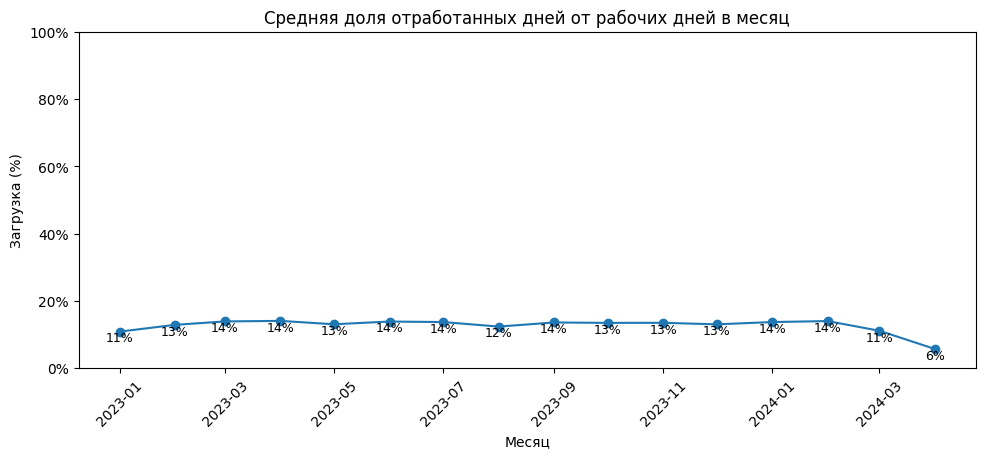

In [12]:
monthly_utilization['utilization_ratio'] = monthly_utilization['worked_days'] / monthly_utilization['month_days']

util_ratio_avg = monthly_utilization.groupby('dt_month')['utilization_ratio'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(util_ratio_avg['dt_month'], util_ratio_avg['utilization_ratio'], marker='o', label='Utilization Ratio')

# Подписи на графике — в процентах
for i, row in util_ratio_avg.iterrows():
    plt.text(row['dt_month'], row['utilization_ratio'] - 0.03,
             f"{row['utilization_ratio'] * 100:.0f}%", ha='center', fontsize=9)

plt.title('Средняя доля отработанных дней от рабочих дней в месяц')
plt.xlabel('Месяц')
plt.ylabel('Загрузка (%)')
plt.grid(False)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # 1.0 = 100%
plt.tight_layout()
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

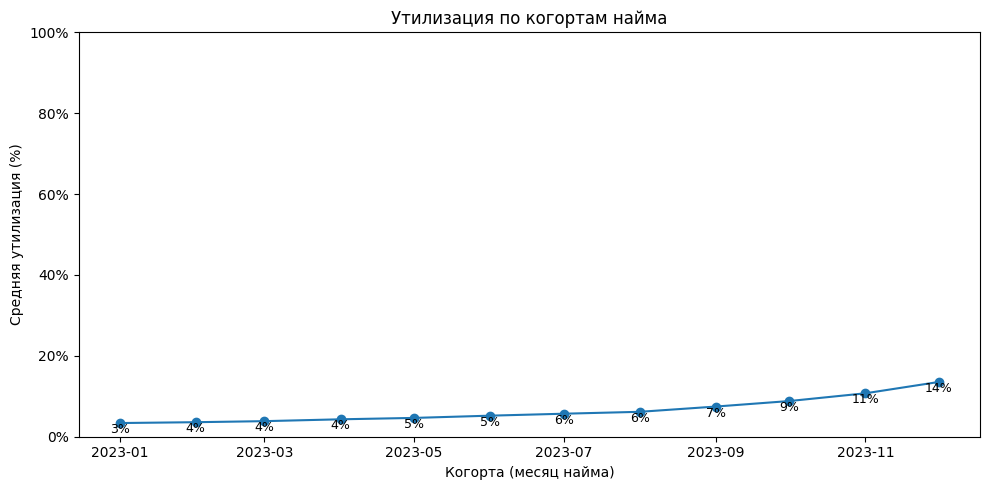

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(cohort_utilization['cohort'], cohort_utilization['avg_utilization'], marker='o', label='Avg Utilization')


for i, row in cohort_utilization.iterrows():
    plt.text(row['cohort'], row['avg_utilization'] - 0.025,
             f"{row['avg_utilization'] * 100:.0f}%", ha='center', fontsize=9)

plt.title('Утилизация по когортам найма')
plt.xlabel('Когорта (месяц найма)')
plt.ylabel('Средняя утилизация (%)')
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(False)
plt.tight_layout()
plt.show()

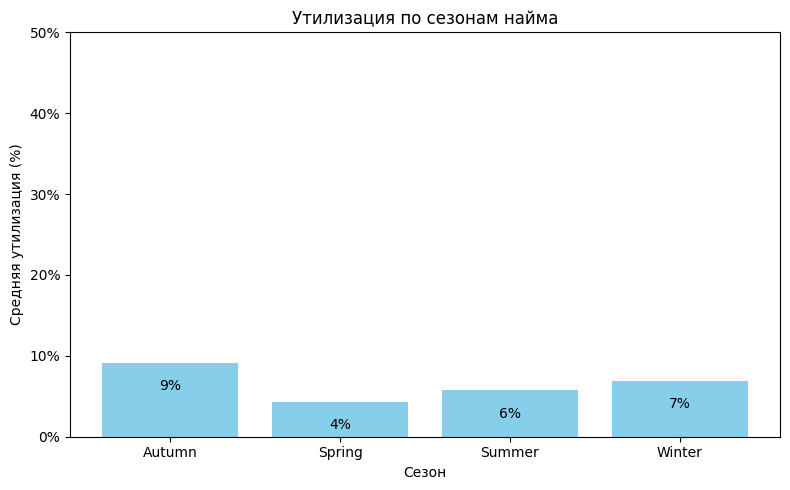

In [15]:
plt.figure(figsize=(8, 5))
bars = plt.bar(seasonal_utilization['season'], seasonal_utilization['avg_utilization'], color='skyblue')

for bar, val in zip(bars, seasonal_utilization['avg_utilization']):
    plt.text(bar.get_x() + bar.get_width()/2, val - 0.02,
             f"{val * 100:.0f}%", ha='center', va='top', fontsize=10)

plt.title('Утилизация по сезонам найма')
plt.xlabel('Сезон')
plt.ylabel('Средняя утилизация (%)')
plt.ylim(0, 0.5)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 
plt.grid(False)
plt.tight_layout()
plt.show()



In [16]:
end_month = df1['dt_month'].max()

salary_records = []

for _, row in df2.iterrows():
    months = pd.date_range(start=row['dt_month'], end=end_month, freq='MS')
    for m in months:
        salary_records.append({'id': row['id'], 'dt_month': m, 'salary': row['salary']})

salary_df = pd.DataFrame(salary_records)

# Общая сумма ФОТ по месяцам
fot_monthly = salary_df.groupby('dt_month').agg(
    total_fot=('salary', 'sum'),
    employees_on_payroll=('id', 'nunique'),
    avg_salary_all=('salary', 'mean')
).reset_index()

# Средняя зарплата среди **активных** сотрудников
active_employees = df1.groupby('dt_month').agg(
    active_employee_ids=('id', pd.Series.nunique)
).reset_index()

# Присоединим зарплаты сотрудников, реально работавших в конкретный месяц
active_salary_df = df1[['dt_month', 'id']].drop_duplicates().merge(
    df2[['id', 'salary']], on='id', how='left'
)

avg_salary_active = active_salary_df.groupby('dt_month').agg(
    avg_salary_active=('salary', 'mean')
).reset_index()

fot_summary = fot_monthly.merge(avg_salary_active, on='dt_month', how='left')

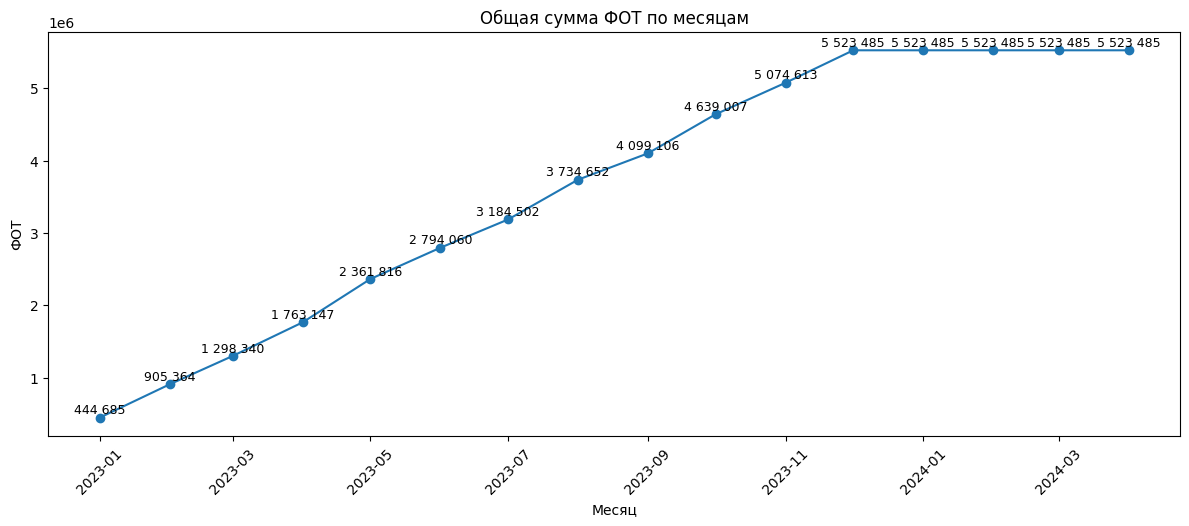

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(fot_summary['dt_month'], fot_summary['total_fot'], marker='o', label='Total Payroll (ФОТ)')

for i, row in fot_summary.iterrows():
    plt.text(row['dt_month'], row['total_fot'] + 0.01 * fot_summary['total_fot'].max(),
             f"{int(row['total_fot']):,}".replace(",", " "), ha='center', fontsize=9)

plt.title('Общая сумма ФОТ по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ФОТ')
plt.grid(False)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


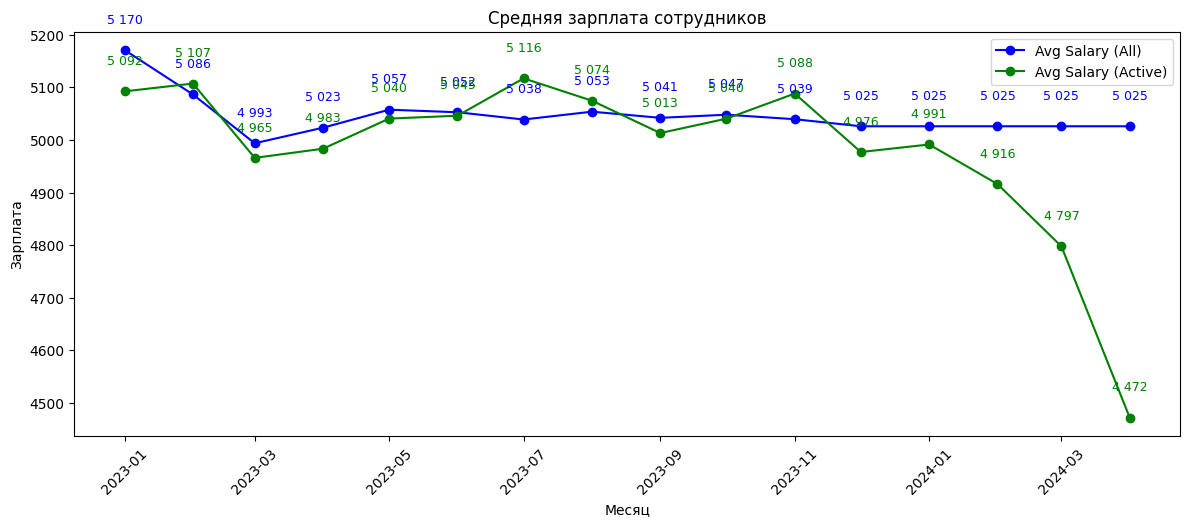

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(fot_summary['dt_month'], fot_summary['avg_salary_all'], marker='o', label='Avg Salary (All)', color='blue')
plt.plot(fot_summary['dt_month'], fot_summary['avg_salary_active'], marker='o', label='Avg Salary (Active)', color='green')

for i, row in fot_summary.iterrows():
    plt.text(row['dt_month'], row['avg_salary_all'] + 0.01 * fot_summary['avg_salary_all'].max(),
             f"{int(row['avg_salary_all']):,}".replace(",", " "), ha='center', fontsize=9, color='blue')

    plt.text(row['dt_month'], row['avg_salary_active'] + 0.01 * fot_summary['avg_salary_active'].max(),
             f"{int(row['avg_salary_active']):,}".replace(",", " "), ha='center', fontsize=9, color='green')

plt.title('Средняя зарплата сотрудников')
plt.xlabel('Месяц')
plt.ylabel('Зарплата')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [20]:
df1['dt'] = pd.to_datetime(df1['dt'])
df2['dt_start'] = pd.to_datetime(df2['dt_start'])

df1['dt_month'] = df1['dt'].dt.to_period('M').dt.to_timestamp()
df2['cohort'] = df2['dt_start'].dt.to_period('M').dt.to_timestamp()

df_merged = df1.merge(df2[['id', 'dt_start', 'cohort']], on='id', how='left')

df_merged['months_since_start'] = (
    (df_merged['dt_month'].dt.year - df_merged['dt_start'].dt.year) * 12 +
    (df_merged['dt_month'].dt.month - df_merged['dt_start'].dt.month)
)

cohort_analysis = df_merged.groupby(['cohort', 'months_since_start']).agg(
    employees=('id', pd.Series.nunique),
    total_days=('dt', 'nunique'),
    total_crystals=('crystals', 'sum')
).reset_index()

cohort_analysis['productivity'] = cohort_analysis['total_crystals'] / cohort_analysis['total_days']




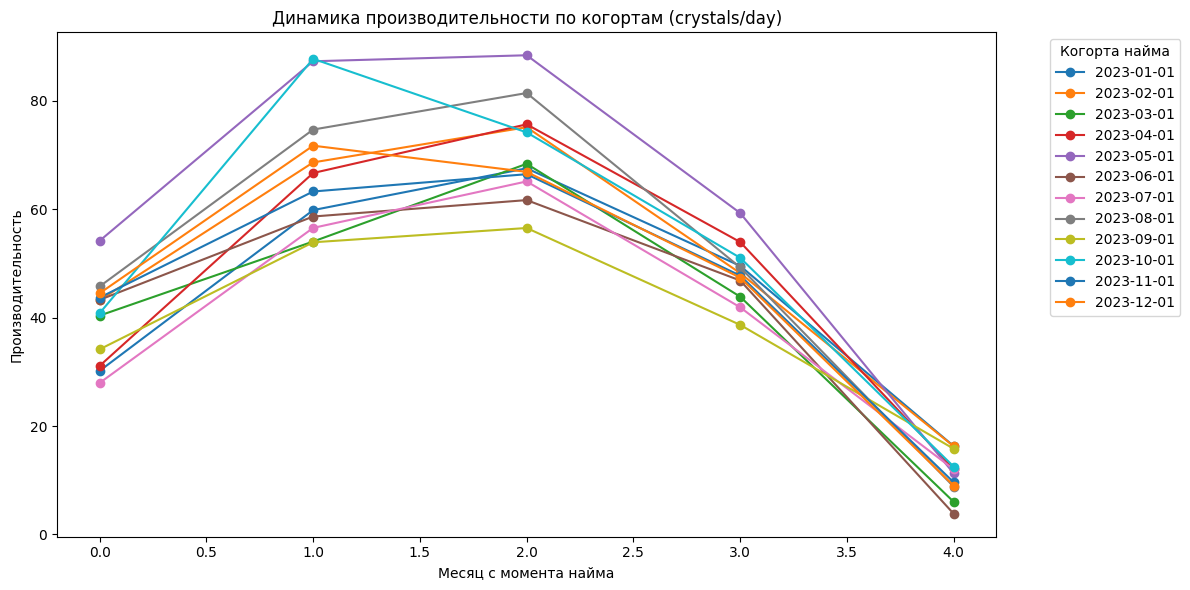

In [21]:
plt.figure(figsize=(12, 6))
for cohort, group in cohort_analysis.groupby('cohort'):
    plt.plot(group['months_since_start'], group['productivity'], marker='o', label=str(cohort.date()))

plt.title('Динамика производительности по когортам (crystals/day)')
plt.xlabel('Месяц с момента найма')
plt.ylabel('Производительность')
plt.legend(title='Когорта найма', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.show()


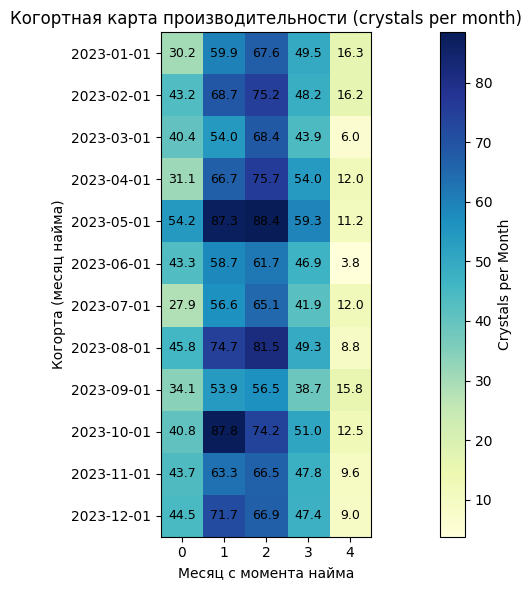

In [31]:
heatmap_data = cohort_analysis.pivot_table(
    index='cohort',
    columns='months_since_start',
    values='productivity',
    aggfunc='mean'
).sort_index()


data = heatmap_data.values
cohorts = [str(c.date()) for c in heatmap_data.index]
months = heatmap_data.columns.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(data, cmap="YlGnBu")

ax.set_xticks(np.arange(len(months)))
ax.set_yticks(np.arange(len(cohorts)))
ax.set_xticklabels(months)
ax.set_yticklabels(cohorts)
ax.set_xlabel("Месяц с момента найма")
ax.set_ylabel("Когорта (месяц найма)")
plt.title("Когортная карта производительности (crystals per month)")

for i in range(len(cohorts)):
    for j in range(len(months)):
        value = data[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="black", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Crystals per Month')

plt.tight_layout()
plt.show()

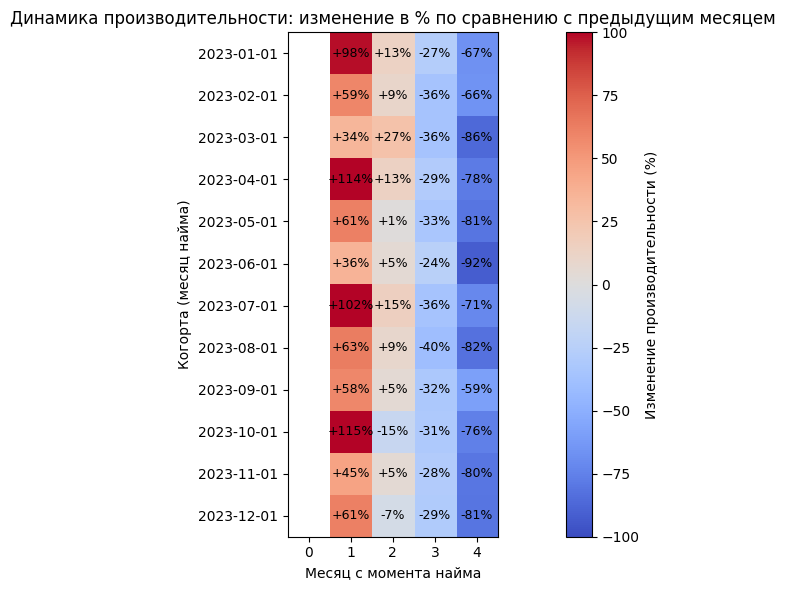

In [23]:
productivity_matrix = cohort_analysis.pivot_table(
    index='cohort',
    columns='months_since_start',
    values='productivity',
    aggfunc='mean'
).sort_index()

productivity_pct_change = productivity_matrix.pct_change(axis=1) * 100

data = productivity_pct_change.values
cohorts = [str(c.date()) for c in productivity_pct_change.index]
months = productivity_pct_change.columns.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(data, cmap="coolwarm", vmin=-100, vmax=100)

ax.set_xticks(np.arange(len(months)))
ax.set_yticks(np.arange(len(cohorts)))
ax.set_xticklabels(months)
ax.set_yticklabels(cohorts)
ax.set_xlabel("Месяц с момента найма")
ax.set_ylabel("Когорта (месяц найма)")
plt.title("Динамика производительности: изменение в % по сравнению с предыдущим месяцем")

for i in range(len(cohorts)):
    for j in range(len(months)):
        value = data[i, j]
        if not np.isnan(value):
            text = f"{value:+.0f}%"  
            ax.text(j, i, text, ha="center", va="center", fontsize=9, color="black")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Изменение производительности (%)')

plt.tight_layout()
plt.show()